In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter

# Word Cloud
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving reviews.csv to reviews (1).csv


In [ ]:
df = pd.read_csv("reviews.csv")

df.head()
df.tail()
df.sample(5)
df.shape
df.info()
df.dtypes
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  56000 non-null  object
 1   review  56000 non-null  object
dtypes: object(2)
memory usage: 875.1+ KB


np.int64(6)

In [ ]:
#CLASS DISTRIBUTION
df['rating'].value_counts()
df['rating'].value_counts(normalize=True)*100

,proportion
rating,
negative,50.0
positive,50.0


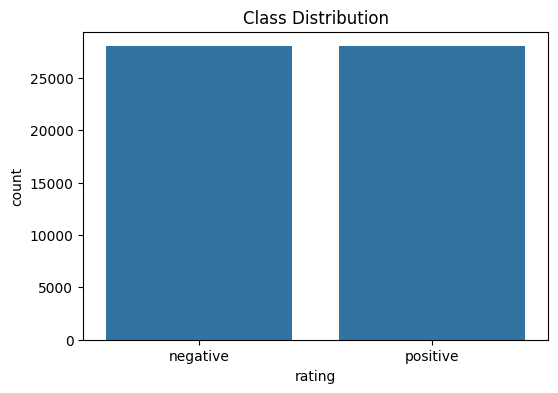

In [ ]:
#BAR PLOT
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='rating')

plt.title("Class Distribution")

plt.show()

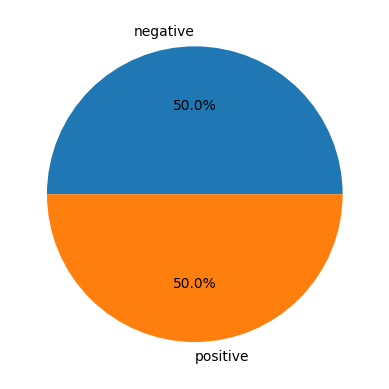

In [ ]:
#PIE CHART
df['rating'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.show()

In [ ]:
#CHARACTER COUNT
df['Character_Count']=df['review'].str.len()

df.head()

,rating,review,Character_Count,Word_Count,Sentence_Count
0,negative,terrible place to work for i just heard a stor...,513,106,5
1,negative,"hours , minutes total time for an extremely s...",110,22,4
2,negative,my less than stellar review is for service . w...,533,104,7
3,negative,i m granting one star because there s no way t...,578,125,5
4,negative,the food here is mediocre at best . i went aft...,330,67,4


In [ ]:
#WORD COUNT
df['Word_Count']=df['review'].apply(lambda x: len(str(x).split()))

df

,rating,review,Character_Count,Word_Count
0,negative,terrible place to work for i just heard a stor...,513,106
1,negative,"hours , minutes total time for an extremely s...",110,22
2,negative,my less than stellar review is for service . w...,533,104
3,negative,i m granting one star because there s no way t...,578,125
4,negative,the food here is mediocre at best . i went aft...,330,67
...,...,...,...,...
55995,positive,"great food . wonderful , friendly service . i ...",65,12
55996,positive,charlotte should be the new standard for moder...,961,198
55997,positive,get the encore sandwich ! ! make sure to get i...,86,20
55998,positive,i m a pretty big ice cream gelato fan . pretty...,609,125


In [ ]:
#SENTENCE COUNT
nltk.download('punkt_tab')
df['Sentence_Count']=df['review'].apply( lambda x: len(sent_tokenize(str(x))))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#AVERAGE LENGTH COUNT
df['Word_Count'].mean()

np.float64(146.15951785714284)

In [ ]:
df['Word_Count'].max()



135.62242923635247

In [ ]:
df['Word_Count'].std()

In [ ]:
df['Word_Count'].median()

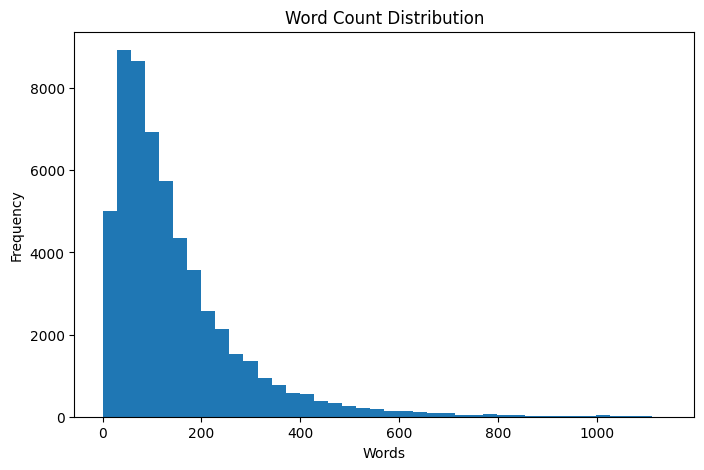

In [ ]:
#HISTOGRAM
plt.figure(figsize=(8,5))

plt.hist(df['Word_Count'],bins=40)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Word Count Distribution")

plt.show()

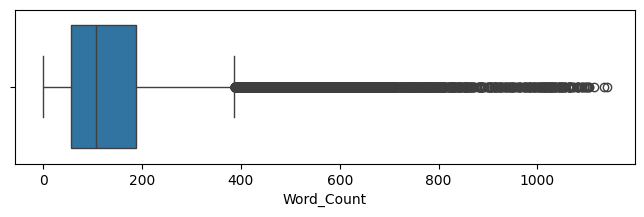

In [ ]:
#BOX PLOT
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Word_Count'])

plt.show()

In [ ]:
#Longest Review
df.loc[df['Word_Count'].idxmax()]

,2978
rating,negative
review,part one as of now i will say i give it two st...
Character_Count,5070
Word_Count,1140
Sentence_Count,94


In [ ]:
#Shortest Review
df.loc[df['Word_Count'].idxmin()]

,15434
rating,negative
review,
Character_Count,1
Word_Count,0
Sentence_Count,0


In [ ]:
#Convert Reviews into One Corpus
corpus=" ".join(df['review'].astype(str))

In [ ]:
#Tokenization
tokens=word_tokenize(corpus)

tokens[:50]

['terrible',
 'place',
 'to',
 'work',
 'for',
 'i',
 'just',
 'heard',
 'a',
 'story',
 'of',
 'them',
 'find',
 'a',
 'girl',
 'over',
 'her',
 'biological',
 'father',
 'coming',
 'in',
 'there',
 'who',
 'she',
 'hadn',
 't',
 'seen',
 'in',
 'years',
 'she',
 'said',
 'hi',
 'to',
 'him',
 'which',
 'upset',
 'his',
 'wife',
 'and',
 'they',
 'left',
 'she',
 'finished',
 'the',
 'rest',
 'of',
 'her',
 'day',
 'working',
 'fine']

In [ ]:
#TOTAL TOKENS
len(tokens)

8186641

In [ ]:
#Vocabulary Size
vocabulary=set(tokens)

len(vocabulary)

61844

In [ ]:
# Lexical Diversity
len(vocabulary)/len(tokens)

0.007554258211640159

In [ ]:
#Most Frequent Words
Counter(tokens).most_common(20)

[('.', 528735),
 ('the', 339990),
 (',', 257289),
 ('and', 231288),
 ('i', 225732),
 ('to', 185031),
 ('a', 179478),
 ('was', 117940),
 ('it', 106288),
 ('of', 103076),
 ('for', 83622),
 ('in', 82762),
 ('is', 82250),
 ('n', 75090),
 ('that', 73885),
 ('my', 70406),
 ('!', 69968),
 ('they', 61324),
 ('this', 58229),
 ('you', 57180)]

In [ ]:
# Frequency Table
freq=pd.DataFrame(
    Counter(tokens).most_common(20),
    columns=['Word','Frequency']
)

freq

,Word,Frequency
0,.,528735
1,the,339990
2,",",257289
3,and,231288
4,i,225732
5,to,185031
6,a,179478
7,was,117940
8,it,106288
9,of,103076


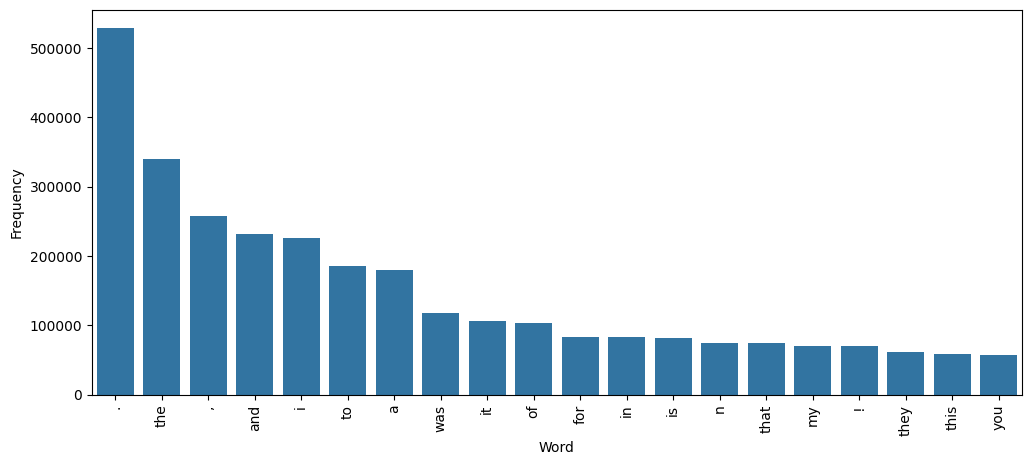

In [ ]:
# Bar Graph of Frequent Words
plt.figure(figsize=(12,5))

sns.barplot(
    data=freq,
    x='Word',
    y='Frequency'
)

plt.xticks(rotation=90)

plt.show()

In [ ]:
# Stop Words
stop_words=set(stopwords.words('english'))

filtered=[
    word.lower()
    for word in tokens
    if word.lower() not in stop_words
]

In [ ]:
#Frequent Words Without Stopwords
Counter(filtered).most_common(20)

[('.', 528735),
 (',', 257289),
 ('n', 75090),
 ('!', 69968),
 ('food', 30922),
 ('place', 30625),
 ('good', 28302),
 ('like', 25130),
 ('get', 23051),
 ('one', 22778),
 ('time', 21566),
 ('would', 20499),
 ('service', 20286),
 ('great', 19872),
 ('back', 19241),
 ('go', 19068),
 ('?', 18513),
 ('really', 15020),
 ('even', 13484),
 ('ni', 13198)]

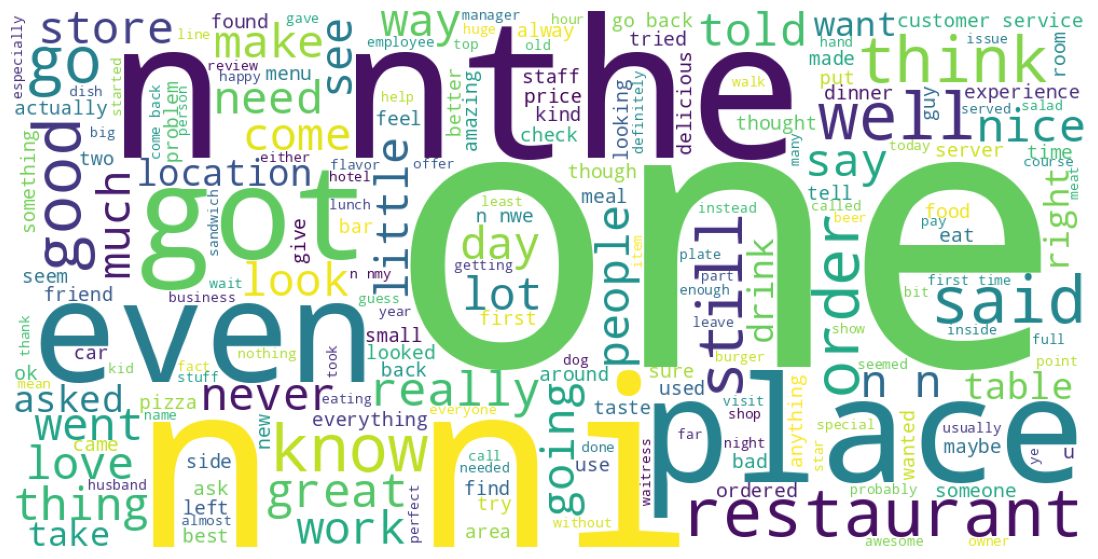

In [ ]:
# Word Cloud
wordcloud=WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(filtered))

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
# Unigrams
unigrams=list(ngrams(filtered,1))

Counter(unigrams).most_common(20)

[(('.',), 528735),
 ((',',), 257289),
 (('n',), 75090),
 (('!',), 69968),
 (('food',), 30922),
 (('place',), 30625),
 (('good',), 28302),
 (('like',), 25130),
 (('get',), 23051),
 (('one',), 22778),
 (('time',), 21566),
 (('would',), 20499),
 (('service',), 20286),
 (('great',), 19872),
 (('back',), 19241),
 (('go',), 19068),
 (('?',), 18513),
 (('really',), 15020),
 (('even',), 13484),
 (('ni',), 13198)]

In [ ]:
#Bigrams
bigrams=list(ngrams(filtered,2))

Counter(bigrams).most_common(20)

[(('.', '.'), 70939),
 (('.', 'n'), 56211),
 (('!', '!'), 16999),
 (('n', 'ni'), 10914),
 (('n', 'nthe'), 8639),
 (('!', 'n'), 6867),
 (('good', '.'), 5739),
 (('place', '.'), 5212),
 (('food', '.'), 4990),
 (('.', 'also'), 4803),
 (('.', ','), 4671),
 (('back', '.'), 4471),
 (('.', 'food'), 4450),
 (('time', '.'), 4099),
 (('service', '.'), 3921),
 (('n', 'n'), 3888),
 (('.', 'place'), 3768),
 (('.', 'great'), 3684),
 (('.', 'one'), 3570),
 (('customer', 'service'), 3432)]

In [ ]:
#Trigram
trigrams=list(ngrams(filtered,3))

Counter(trigrams).most_common(20)

[(('.', '.', '.'), 37717),
 (('.', 'n', 'ni'), 9058),
 (('!', '!', '!'), 8167),
 (('.', 'n', 'nthe'), 7418),
 (('.', 'n', 'n'), 2528),
 (('.', '.', 'n'), 2135),
 (('.', 'n', 'nwe'), 2040),
 (('.', 'n', 'nmy'), 1507),
 (('.', 'however', ','), 1390),
 (('.', 'n', 'nthis'), 1154),
 (('!', 'n', 'ni'), 1126),
 (('.', 'n', 'nthey'), 1082),
 (('.', 'n', 'nit'), 1049),
 ((',', 'etc', '.'), 1031),
 (('?', '?', '?'), 1021),
 (('!', '!', 'n'), 994),
 (('.', 'n', 'nso'), 972),
 (('.', 'n', 'nif'), 903),
 (('customer', 'service', '.'), 879),
 (('go', 'back', '.'), 853)]

In [ ]:
#Bigram DataFrame
bigram_freq=pd.DataFrame(
    Counter(bigrams).most_common(20),
    columns=['Bigram','Frequency']
)

bigram_freq

,Bigram,Frequency
0,"(., .)",70939
1,"(., n)",56211
2,"(!, !)",16999
3,"(n, ni)",10914
4,"(n, nthe)",8639
5,"(!, n)",6867
6,"(good, .)",5739
7,"(place, .)",5212
8,"(food, .)",4990
9,"(., also)",4803


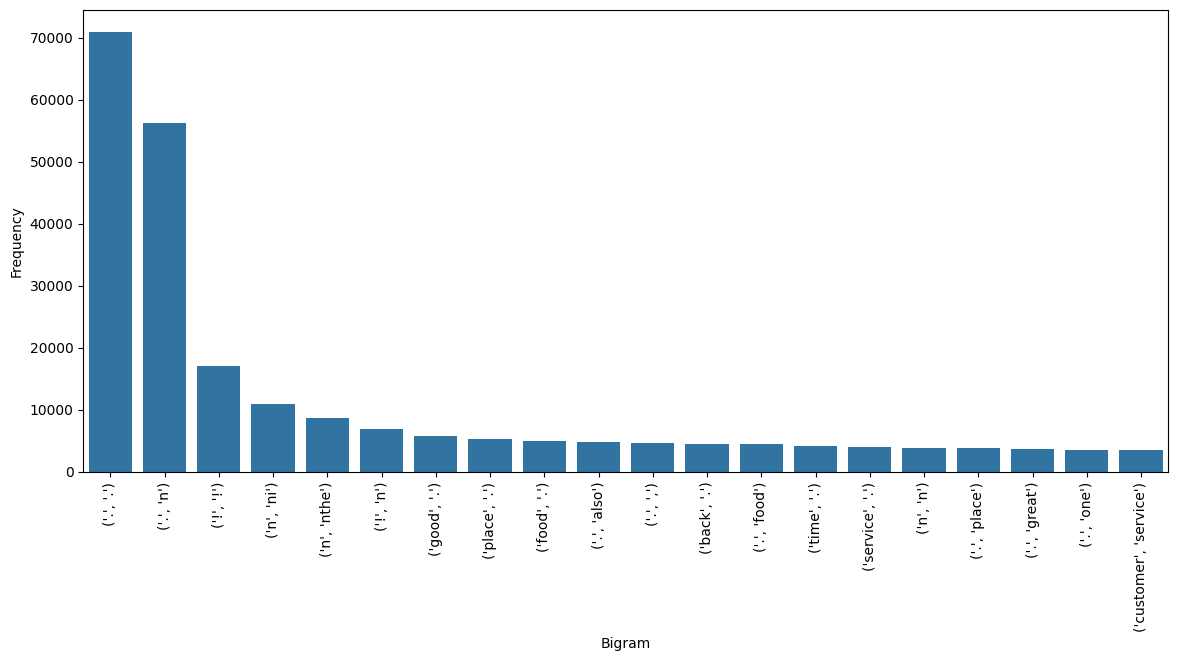

In [ ]:
# Bigram Plot
bigram_freq['Bigram']=bigram_freq['Bigram'].astype(str)

plt.figure(figsize=(14,6))

sns.barplot(
    data=bigram_freq,
    x='Bigram',
    y='Frequency'
)

plt.xticks(rotation=90)

plt.show()

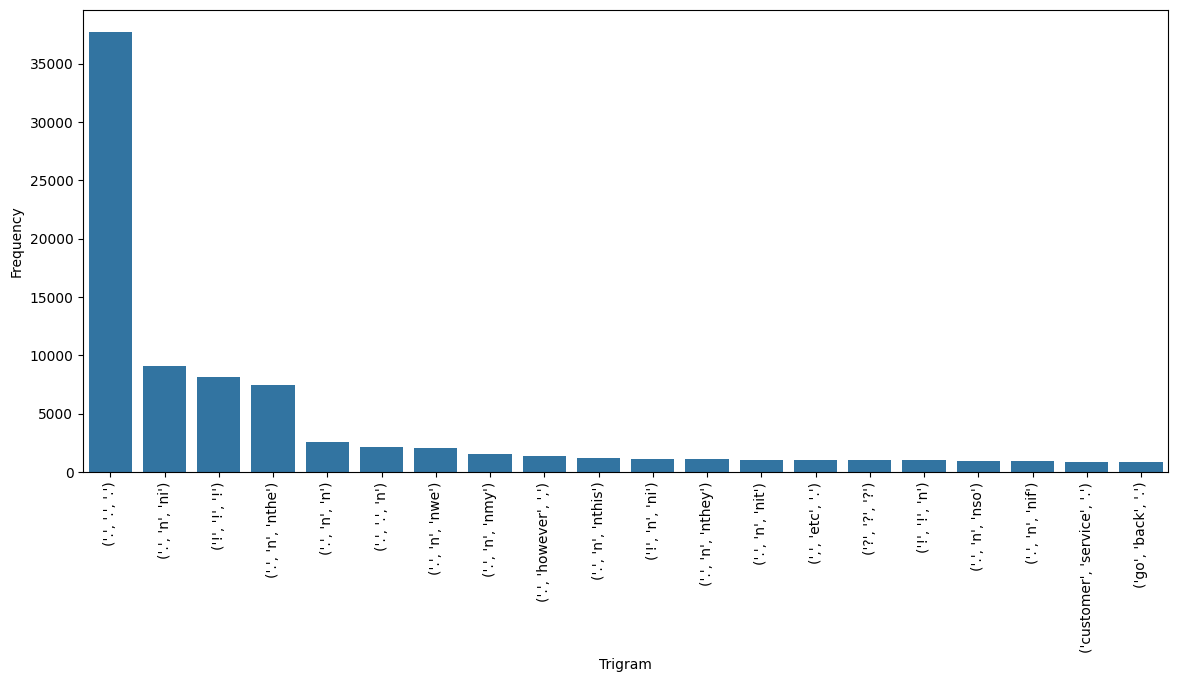

In [ ]:
#Trigram Plot
trigram_freq=pd.DataFrame(
    Counter(trigrams).most_common(20),
    columns=['Trigram','Frequency']
)

trigram_freq['Trigram']=trigram_freq['Trigram'].astype(str)

plt.figure(figsize=(14,6))

sns.barplot(
    data=trigram_freq,
    x='Trigram',
    y='Frequency'
)

plt.xticks(rotation=90)

plt.show()

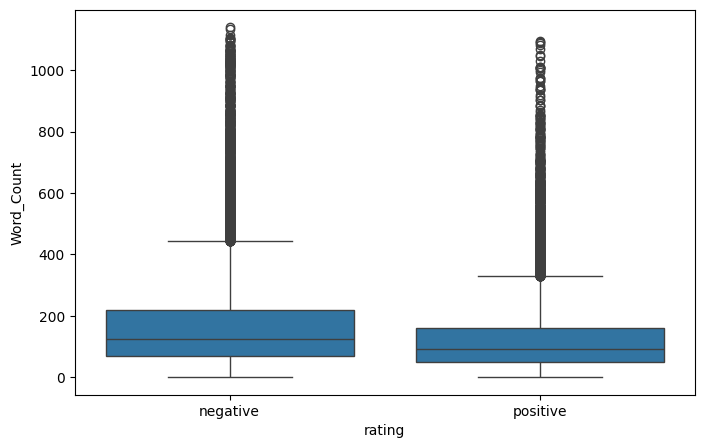

In [ ]:
# Positive vs Negative Review Length
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='rating',
    y='Word_Count'
)

plt.show()

In [ ]:
# Top Positive Words
positive=" ".join(
    df[df['rating']=="positive"]['review']
)

positive_tokens=word_tokenize(positive)

Counter(positive_tokens).most_common(20)

[('.', 219403),
 ('the', 142436),
 (',', 116463),
 ('and', 106119),
 ('i', 88586),
 ('a', 81514),
 ('to', 68426),
 ('of', 46112),
 ('it', 44542),
 ('is', 44390),
 ('was', 41344),
 ('!', 38690),
 ('for', 36144),
 ('in', 35798),
 ('n', 34579),
 ('you', 28545),
 ('my', 27271),
 ('that', 26742),
 ('with', 24986),
 ('they', 24037)]

In [ ]:
# Top Negative Words
negative=" ".join(
    df[df['rating']=="negative"]['review']
)

negative_tokens=word_tokenize(negative)

Counter(negative_tokens).most_common(20)

[('.', 309332),
 ('the', 197554),
 (',', 140826),
 ('i', 137146),
 ('and', 125169),
 ('to', 116605),
 ('a', 97964),
 ('was', 76596),
 ('it', 61746),
 ('of', 56964),
 ('for', 47478),
 ('that', 47143),
 ('in', 46964),
 ('my', 43135),
 ('n', 40511),
 ('is', 37860),
 ('they', 37287),
 ('not', 35043),
 ('t', 34915),
 ('this', 34803)]

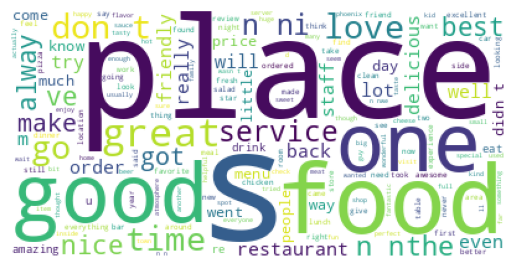

In [ ]:
#Positive Word Cloud
wordcloud=WordCloud(
    background_color="white"
).generate(positive)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

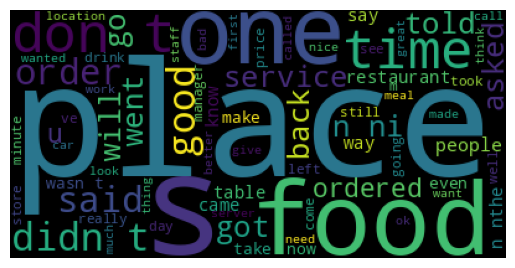

In [ ]:
# Negative Word Cloud
wordcloud=WordCloud(
    background_color="black"
).generate(negative)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()